In [ ]:
# GPU support

# This library can use CuPy for GPU acceleration.
# We recommend installing CuPy via conda-forge:
# conda install -c conda-forge cupy cuda-version=12.4


Best fitness: 0.07847769983579798
sum of Bx: 2602.5058533711394
sum of By: 526.0330064613588
sum of Bz: 3.0580816864991276e-06
Run 1/1 done, best fitness = 7.848e-02
Best angles (rad): [ 0.         -0.26179939 -0.26179939 -0.26179939  0.          0.26179939
  0.26179939  0.26179939  0.         -0.26179939 -0.26179939 -0.26179939
  0.          0.26179939  0.26179939  0.26179939]


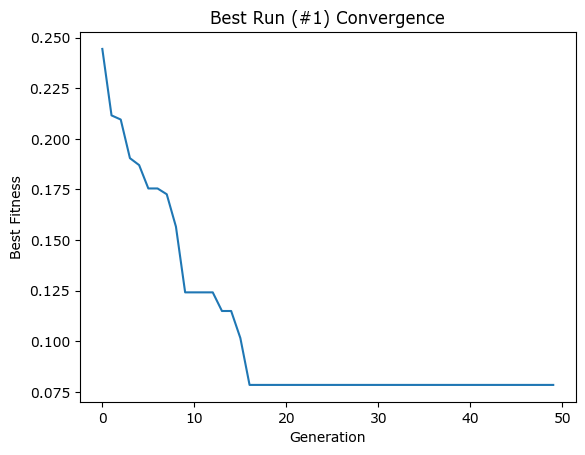

Best angles (rad): [ 0.         -0.26179939 -0.26179939 -0.26179939  0.          0.26179939
  0.26179939  0.26179939  0.         -0.26179939 -0.26179939 -0.26179939
  0.          0.26179939  0.26179939  0.26179939]
Best fitness: 7.847770e-02


In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from magoptlib.genetic_algorithm import genetic_algorithm_gpu
from magoptlib.sh_fitting import precompute_sh_coeffs, get_m_l_vals
from magoptlib.sh_gpu import get_orientations_gpu
from magoptlib.synthetic_measurement import simulate_magnetic_measurement
from magoptlib.pos import magnetring, sensorring

# ============================================================
# Initialization
# ============================================================

n_magnets = 16 # Number of magnets in the Halbach ring
n_theta = 18 # Number of theta for the Fibonacci lattice sampling
n_phi   = 36 # Number of phi for the Fibonacci lattice sampling
radius = 20.0 # Radius of the measurement sphere

max_sh_order = 24

m_values, l_values = get_m_l_vals(max_sh_order)

# Initial angles for the magnets
init_angles = cp.linspace(0, 4*np.pi, n_magnets, endpoint=False, dtype=np.float64)

positions_cpu, init_orientations_gpu = magnetring(n_magnets, init_angles, radius = 40)
points_of_interest = sensorring(24, radius=20)

Bx, By, Bz, theta_values, phi_values = simulate_magnetic_measurement(n_theta, n_phi, n_magnets, radius, noise_level=0.01, noise=False)

sh_coeff_X, sh_coeff_Y, sh_coeff_Z = precompute_sh_coeffs(Bx, By, Bz, theta_values, phi_values, n_magnets, radius, max_sh_order)

positions_gpu = cp.asarray(positions_cpu)           # (8,3)
l_vals_cpu = l_values
m_vals_cpu = m_values
shZ_gpu = cp.asarray(sh_coeff_Z, dtype=cp.float64)  
shX_gpu = cp.asarray(sh_coeff_X, dtype=cp.float64)
shY_gpu = cp.asarray(sh_coeff_Y, dtype=cp.float64)
pG_cpu = points_of_interest
pG_gpu = cp.asarray(pG_cpu)


possible_angles_cpu = np.linspace(-15*np.pi/180, 15*np.pi/180, 3, dtype=np.float64)
possible_angles_gpu = cp.asarray(possible_angles_cpu, dtype=cp.float64)


# GA parameters
pop_size   = 100
num_gens   = 50
mut_rate   = 0.3

# Penalty multiplier for By and Bz
alpha      = 1e8

# Number of restarts
n_restarts = 1


# Preallocate storage
d = positions_cpu.shape[0]   # number of magnets
best_angles     = np.zeros((n_restarts, d))
best_fitness    = np.zeros(n_restarts)
Bx_best         = np.zeros(n_restarts)
By_best         = np.zeros(n_restarts)
Bz_best         = np.zeros(n_restarts)
fitness_history = np.zeros((n_restarts, num_gens))


for run in range(n_restarts):

    (best_angles[run],
        best_fitness[run],
        _,
        _,
        _,
        fitness_history[run]
    ) = genetic_algorithm_gpu(
        positions_cpu, 
        init_orientations_gpu,
        l_values, m_values,
        sh_coeff_Z, sh_coeff_X, sh_coeff_Y, pG_cpu,
        possible_angles_cpu,
        population_size=pop_size,
        generations=num_gens,
        mutation_rate=mut_rate,
        alpha=alpha
        # TODO objective='maxBx' # maximize Bx or ='homogeneity' for minimizing |B_max - B_min|/|B_abs|
    )
    print(f"Run {run+1}/{n_restarts} done, best fitness = {best_fitness[run]:.3e}")
    print(f"Best angles (rad): {best_angles[run]}")

best_run = np.argmin(best_fitness) # min fitness wins
# best_run = np.argmax(best_fitness) # max fitness wins



plt.plot(fitness_history[best_run])
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title(f"Best Run (#{best_run+1}) Convergence")
plt.show()
print("Best angles (rad):", best_angles[best_run])
print(f"Best fitness: {best_fitness[best_run]:.6e}")

In [ ]:

# # Upload static data to GPU
# positions_cpu = np.array([
#     (40*np.cos(2*np.pi*i/n_magnets), 40*np.sin(2*np.pi*i/n_magnets), 0.0)
#     for i in range(n_magnets)
# ], dtype=np.float64) 

# # Initial orientations of the magnets
# Ry90 = cp.array([[0.0, 0.0, 1.0],
#                     [0.0, 1.0, 0.0],
#                     [-1.0, 0.0, 0.0]], dtype=cp.float64)

# init_rot_batch = cp.zeros((n_magnets,3,3), dtype=cp.float64)
# init_rot_batch[:, 0, 0] = cp.cos(init_angles)
# init_rot_batch[:, 0, 1] = -cp.sin(init_angles)
# init_rot_batch[:, 1, 0] = cp.sin(init_angles)
# init_rot_batch[:, 1, 1] = cp.cos(init_angles)
# init_rot_batch[:, 2, 2] = 1.0

# init_orientations_gpu = cp.matmul(init_rot_batch, Ry90)  


# # Create points of interest for the fitness function 
# num_points = 24
# points_of_interest = np.zeros((num_points, 3), dtype=np.float64)
# for i in range(num_points):
#     angle = 2 * np.pi * i/num_points
#     x = 20 * np.cos(angle)
#     y = 20 * np.sin(angle)
#     points_of_interest [i] = (x, y, 0.0)